# 马尔可夫链与MCMC采样

学习目标：从转移矩阵计算状态分布与平稳分布，实现最小 Gibbs 采样，并结合初始状态、样本相关性和重复实验判断估计的局限。

前置知识：条件概率与联合分布、矩阵乘法、期望与方差、蒙特卡洛样本平均；Python 循环、函数和 NumPy 数组。

运行环境：Python 3.12、NumPy 2.5、Matplotlib 3.11。本章为扩展内容，只使用有限状态的教学模拟，无需外部数据。

环境准备：[环境配置与运行](README.md)。

工作目录：本 Notebook 所在目录；重启内核后从上到下运行。

## 1 下一步由当前状态决定

一个教学装置每一步处于状态 0 或 1。从 0 出发，下一步以 0.2 的概率变成 1；从 1 出发，以 0.3 的概率变成 0，其余概率留在原状态。这是人为规定的模型，不是实际设备记录。

先从每个圆出发，把所有出边的概率相加。留在原状态也占用概率，因此不能漏掉自环。

![状态 0 自环为 0.8、到 1 为 0.2，状态 1 自环为 0.7、到 0 为 0.3；旁边矩阵按当前状态分行。](image/illustration/28-01-markov-transition.svg)

箭头标的是一步转移概率，不是某条实际路径；矩阵的行对应当前状态，列对应下一状态。两方向的概率不必相同。

用 $X_t$ 表示第 t 步状态，$t=0,1,2,\ldots$。马尔可夫性质（Markov property）表示给定当前状态后，下一步的条件分布不再依赖更早状态。在条件事件有正概率时，

$$P(X_{t+1}=j\mid X_t=i,X_{t-1},\ldots,X_0)=P(X_{t+1}=j\mid X_t=i)。$$

i、j 是状态编号。该性质不表示相邻状态独立。本章还假设转移规律不随 t 改变，即时间齐次。下面把图中四条边依次放入矩阵，再核对每行概率和。

In [1]:
import matplotlib.pyplot as plt
import numpy as np

transition = np.array([[0.8, 0.2], [0.3, 0.7]])
print("转移矩阵：\n", transition)  # 预期约为 [[0.8 0.2] [0.3 0.7]]。
print("每行概率和：", transition.sum(axis=1))  # 预期为 [1. 1.]。
print("从 0 到 1 与从 1 到 0：", transition[0, 1], transition[1, 0])  # 预期约为 0.2 0.3。
# 行是当前状态，列是下一状态；两个方向的概率不必相同。

转移矩阵：
 [[0.8 0.2]
 [0.3 0.7]]
每行概率和： [1. 1.]
从 0 到 1 与从 1 到 0： 0.2 0.3


## 2 转移矩阵怎样推进分布

对 K 个有限状态，Pᵢⱼ=P(Xₜ₊₁=j|Xₜ=i) 构成 K×K 矩阵 P，各元素非负且每行和为 1。用长度 K 的数学行向量 μₜ 表示第 t 步各状态的概率；NumPy 中用一维数组存储。

全概率公式给出

$$\mu_{t+1,j}=\sum_{i=0}^{K-1}\mu_{t,i}P_{ij},\qquad
\mu_{t+1}=\mu_tP,\qquad\mu_t=\mu_0P^t。$$

例如从状态 0 确定出发，μ₀=(1,0)。两步后到达状态 1 的概率为 0.8×0.2+0.2×0.7=0.3。这里计算整个随机实验的分布，不是在描述某一条路径必然经历什么。

In [2]:
initial_distribution = np.array([1.0, 0.0])
after_one = initial_distribution @ transition
after_two = initial_distribution @ np.linalg.matrix_power(transition, 2)
print("一步与两步后的分布：", after_one, after_two)  # 预期约为 [0.8 0.2] [0.7 0.3]。
print("两步到达 1 的手算：", 0.8 * 0.2 + 0.2 * 0.7)  # 预期约为 0.3。
# P² 使用矩阵乘法；逐元素 transition**2 不代表两步转移。

一步与两步后的分布： [0.8 0.2] [0.7 0.3]
两步到达 1 的手算： 0.30000000000000004


模拟一条路径时，当前位置决定下一次 choice() 使用哪一行概率。下面的 21 个状态包含初始值以及 20 次更新；用局部 Generator 和固定种子复现这次模拟。

In [3]:
rng_path = np.random.default_rng(2801)
path = np.empty(21, dtype=int)
path[0] = 0
for step in range(1, path.size):
    path[step] = rng_path.choice(2, p=transition[path[step - 1]])
print("一条模拟路径：", path)  # 本次固定种子下为 [0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]。
print("本路径状态 1 的比例：", np.mean(path == 1))  # 本次固定种子下约为 0.047619。
# 状态可能连续重复；这 21 个观测不是 21 次独立抽样。

一条模拟路径： [0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
本路径状态 1 的比例： 0.047619047619047616


## 3 平稳分布是分布的不动点

若概率行向量 π 满足 πP=π，就称为平稳分布（stationary distribution）。如果初始状态已经按 π 抽取，每一步的边际分布都保持 π，但相邻状态仍可能相关。

上例设 π=(a,1−a)。第一个分量给出 a=0.8a+0.3(1−a)，所以 0.5a=0.3，得到 π=(0.6,0.4)。平稳不表示路径停止在某个固定状态。

In [4]:
stationary = np.array([0.6, 0.4])
print("平稳分布推进一步：", stationary @ transition)  # 预期约为 [0.6 0.4]。
print("平稳方程残差：", np.max(np.abs(stationary @ transition - stationary)))  # 本次数值约为 5.6e-17。
print("平稳时 P(X下一步=1 | X当前=1)：", transition[1, 1])  # 预期约为 0.7。
print("平稳时 P(X下一步=1)：", stationary[1])  # 预期约为 0.4。
# 0.7 不等于 0.4，说明边际不变并没有带来相邻独立。

平稳分布推进一步： [0.6 0.4]
平稳方程残差： 5.551115123125783e-17
平稳时 P(X下一步=1 | X当前=1)： 0.7
平稳时 P(X下一步=1)： 0.4


## 4 收敛需要哪些条件

有限状态链若任意两个状态都能沿正概率路径互相到达，称为不可约（irreducible）。它有唯一平稳分布。若每个状态在所有足够大的步数后都能以正概率返回自身，则称为非周期（aperiodic）；每个状态都有正概率原地停留，是容易检查的充分条件。

有限、不可约、非周期的齐次链，从任意初始分布出发都有 μₜ→π。上例两个方向可直接互达且对角元素为正，满足这些条件。这个定理不提供每个问题通用的“运行多少步就够了”。

以下分别从 0 和 1 出发，用矩阵乘法计算概率，图中没有抽样噪声。横轴为更新次数，纵轴为状态 1 的概率。

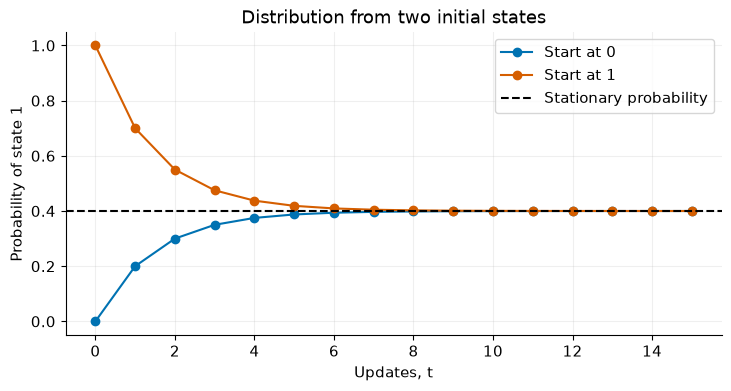

In [5]:
plt.rcParams.update(
    {"font.size": 11, "axes.spines.top": False, "axes.spines.right": False}
)
times = np.arange(16)
distribution_paths = []
# 从两个确定初态分别推进概率行向量；这里计算分布，不是模拟单条轨迹。
for initial in (np.array([1.0, 0.0]), np.array([0.0, 1.0])):
    distribution_paths.append(
        [initial @ np.linalg.matrix_power(transition, int(step)) for step in times]
    )

fig, ax = plt.subplots(figsize=(7.2, 3.8), layout="constrained")
# 每条路径只取状态 1 的概率，并与平稳概率的水平线比较。
for values, color, label in zip(
    distribution_paths, ["#0072B2", "#D55E00"], ["Start at 0", "Start at 1"]
):
    ax.plot(times, np.array(values)[:, 1], "o-", color=color, label=label)
ax.axhline(0.4, color="black", linestyle="--", label="Stationary probability")
ax.set(
    xlabel="Updates, t",
    ylabel="Probability of state 1",
    title="Distribution from two initial states",
)
ax.legend()
ax.grid(alpha=0.2)
# 预期两条状态 1 概率从 0、1 的两侧靠近 0.4 虚线。
plt.show()

两个反例区分条件。若转移矩阵是单位矩阵，状态不能互达，每个初始分布都保持不变。若每步必定从 0 换到 1、从 1 换到 0，链不可约，但只能在偶数步返回原状态；从确定状态出发，分布不断交替。

第二个反例仍有平稳分布 (1/2,1/2)。因此“存在平稳分布”与“任意初始分布都会趋于它”并不等价。

In [6]:
stuck_transition = np.eye(2)
alternating_transition = np.array([[0.0, 1.0], [1.0, 0.0]])
for step in range(4):
    # 不移动链始终为 [1, 0]；交替链在偶数步为 [1, 0]，奇数步为 [0, 1]。
    print(
        "步数",
        step,
        "不移动：",
        initial_distribution @ np.linalg.matrix_power(stuck_transition, step),
        "交替：",
        initial_distribution @ np.linalg.matrix_power(alternating_transition, step),
    )
print("交替链的平稳分布：", np.array([0.5, 0.5]) @ alternating_transition)  # 预期约为 [0.5 0.5]。
# 一条交替路径的长期访问比例仍为各一半；它与时刻 t 的状态分布是不同对象。

步数 0 不移动： [1. 0.] 交替： [1. 0.]
步数 1 不移动： [1. 0.] 交替： [0. 1.]
步数 2 不移动： [1. 0.] 交替： [1. 0.]
步数 3 不移动： [1. 0.] 交替： [0. 1.]
交替链的平稳分布： [0.5 0.5]


## 5 用链的访问记录估计期望

马尔可夫链蒙特卡洛（Markov chain Monte Carlo，MCMC）为目标分布构造合适的链，再用访问记录计算平均值。对本章有限不可约链，遍历定理保证状态访问比例趋于 π；相应地，对实值函数 f，

$$\frac1n\sum_{t=1}^{n}f(X_t)\longrightarrow
E_\pi[f(X)]=\sum_{i=0}^{K-1}\pi_i f(i)\quad\text{几乎必然}。$$

这里 n 是保留的状态数。“几乎必然”指失败路径的概率为零，不是每个有限 n 都准确。这个时间平均结论不要求非周期；非周期还用于任意初始分布的逐时刻分布收敛。

下面估计状态 1 的概率。保留所有重复状态；删掉重复状态会改变时间权重。固定初始状态下，有限长度的平均还可能受起点影响，不能直接宣称无偏。

In [7]:
rng_long = np.random.default_rng(2802)
long_path = np.empty(12000, dtype=int)
current_state = 0
for step in range(long_path.size):
    current_state = rng_long.choice(2, p=transition[current_state])
    long_path[step] = current_state
print("状态比例：", np.bincount(long_path, minlength=2) / long_path.size)  # 本次固定种子下约为 [0.585917 0.414083]。
print("目标比例：", stationary)  # 目标平稳比例固定为 [0.6, 0.4]。
print("状态 1 的本次估计误差：", long_path.mean() - stationary[1])  # 本次固定种子下约为 0.0140833。
# 每次更新后记录一次，包括重复值；本次误差仅是有限模拟结果。

状态比例： [0.58591667 0.41408333]
目标比例： [0.6 0.4]
状态 1 的本次估计误差： 0.014083333333333337


## 6 样本相关性怎样进入标准误

设链已经从平稳分布开始，Yₜ=f(Xₜ)，均值为 μ、方差为 0<σ²<∞。记滞后 k 的自相关为 ρₖ=Cov(Yₜ,Yₜ₊ₖ)/σ²。把平均值方差展开为所有协方差之和，可得有限 n 的精确式：

$$\operatorname{Var}(\overline Y_n)
=\frac{\sigma^2}{n}\left[1+2\sum_{k=1}^{n-1}
\left(1-\frac{k}{n}\right)\rho_k\right]。$$

因为相隔 k 的配对有 n−k 个，便出现这个权重。独立时各个 ρₖ=0，才退化为 σ²/n。不同的 f 可以有不同相关性；这里分析的是特定统计量的波动。

考虑对称两状态链，每步以 a∈(0,1) 的概率翻转。π=(1/2,1/2)，令 Yₜ=Xₜ，则 σ²=1/4。由 E[Xₜ₊₁−1/2|Xₜ]=(1−2a)(Xₜ−1/2)，反复条件期望得到 ρₖ=(1−2a)ᵏ。以下只比较 a≤1/2 的非负相关情形。

In [8]:
variance_n = 1000
lags = np.arange(1, variance_n)
for flip_probability in (0.5, 0.2, 0.01):
    correlation_factor = 1 - 2 * flip_probability
    variance_multiplier = 1 + 2 * np.sum(
        (1 - lags / variance_n) * correlation_factor**lags
    )
    exact_mean_variance = 0.25 / variance_n * variance_multiplier
    # 相关公式 SE 约为 0.01581、0.03159、0.15338；对应方差倍数为 1、3.993、94.1。
    print(
        f"a={flip_probability:.2f}：独立公式 SE={0.5 / np.sqrt(variance_n):.5f}，相关公式 SE={np.sqrt(exact_mean_variance):.5f}，方差倍数={variance_multiplier:.3f}"
    )
# a=0.5 时相邻状态独立；翻转很少时，1000 次记录包含的信息少得多。

a=0.50：独立公式 SE=0.01581，相关公式 SE=0.01581，方差倍数=1.000
a=0.20：独立公式 SE=0.01581，相关公式 SE=0.03159，方差倍数=3.993
a=0.01：独立公式 SE=0.01581，相关公式 SE=0.15338，方差倍数=94.100


若自相关可求和，长链方差可用 σ²τ/n 近似，其中 τ=1+2∑ₖ₌₁∞ρₖ。于是有效样本量（effective sample size，ESS）近似为 n/τ。本例令 λ=1−2a，|λ|<1，几何级数给出 τ=(1+λ)/(1−λ)。

ESS 是对估计精度的等效表达，不是删除了多少行；负相关时它也可能大于 n。下面从 π 独立初始化 800 条链，每条记录 1000 次，比较链均值的实际波动与有限 n 公式。使用整批独立链验证误差尺度，避免假定一条链内的 1000 个值相互独立。

In [9]:
rng_variance = np.random.default_rng(2803)
chain_repetitions = 800
for flip_probability in (0.2, 0.01):
    states = rng_variance.integers(0, 2, size=chain_repetitions)
    sums = np.zeros(chain_repetitions)
    for step in range(variance_n):
        flip = rng_variance.random(chain_repetitions) < flip_probability
        states = np.where(flip, 1 - states, states)
        sums += states
    means = sums / variance_n
    lam = 1 - 2 * flip_probability
    multiplier = 1 + 2 * np.sum((1 - lags / variance_n) * lam**lags)
    # 本次两组均值约 0.4992、0.4998；实验间 SD≈0.03298、0.15894，分别对照理论 SE≈0.03159、0.15338。
    print(
        f"a={flip_probability:.2f}：平均估计={means.mean():.4f}，实验间 SD={means.std(ddof=1):.5f}，理论 SE={np.sqrt(0.25 * multiplier / variance_n):.5f}，渐近 ESS≈{variance_n * (1 - lam) / (1 + lam):.1f}"
    )
# 800 是独立链的条数；输出 SD 衡量每条长度 1000 的链均值的波动。

a=0.20：平均估计=0.4992，实验间 SD=0.03298，理论 SE=0.03159，渐近 ESS≈250.0
a=0.01：平均估计=0.4998，实验间 SD=0.15894，理论 SE=0.15338，渐近 ESS≈10.1


## 7 从两个条件分布构造 Gibbs 更新

Gibbs 采样每次固定其他坐标，从当前坐标的目标条件分布抽样。下面选择二元状态 Z=(X,Y)，X,Y∈{0,1}，目标联合概率表为

$$\pi(x,y)=\begin{pmatrix}0.4&0.1\\0.1&0.4\end{pmatrix},$$

行对应 x、列对应 y。这张表小到可以直接抽样；选择它是为了把目标和算法逐项核对，而不是为了加速已有的简单计算。

每个边际概率均为 0.5，因此 π(X=1|Y=0)=0.2，π(X=1|Y=1)=0.8；Y 给定 X 的条件概率同样可按行归一化得到。四个联合概率都为正，所有这些条件分布都有定义。

In [10]:
joint = np.array([[0.4, 0.1], [0.1, 0.4]])
x_given_y = joint / joint.sum(axis=0, keepdims=True)
y_given_x = joint / joint.sum(axis=1, keepdims=True)
print("联合概率和：", joint.sum())  # 给定联合概率表的总和为 1。
print("X 给定 Y（每列和为 1）：\n", x_given_y)  # 预期约为 [[0.8 0.2] [0.2 0.8]]。
print("Y 给定 X（每行和为 1）：\n", y_given_x)  # 预期约为 [[0.8 0.2] [0.2 0.8]]。
print("目标 E[X] 与 P(X=Y)：", joint[1].sum(), np.trace(joint))  # 预期约为 0.5 0.8。
# 目标分别为 0.5 和 0.8；条件表的归一化轴不同。

联合概率和： 1.0
X 给定 Y（每列和为 1）：
 [[0.8 0.2]
 [0.2 0.8]]
Y 给定 X（每行和为 1）：
 [[0.8 0.2]
 [0.2 0.8]]
目标 E[X] 与 P(X=Y)： 0.5 0.8


本章把一次完整扫描（sweep）定义为先更新 X，再使用新的 X 更新 Y：

$$X_{t+1}\sim\pi(X\mid Y_t),\qquad
Y_{t+1}\sim\pi(Y\mid X_{t+1})。$$

每次完整扫描之后记录二元状态，这样记录序列是一条齐次马尔可夫链。下面先直接写五次更新，再封装为重复实验函数；更新 Y 时不能误用旧的 X。

In [11]:
rng_gibbs_small = np.random.default_rng(2804)
x_state, y_state = 0, 0
for sweep in range(1, 6):
    x_state = int(rng_gibbs_small.random() < x_given_y[1, y_state])
    y_state = int(rng_gibbs_small.random() < y_given_x[x_state, 1])
    print("完整扫描", sweep, "状态", (x_state, y_state))  # 本次五轮状态依次为 (0, 0)、(0, 1)、(1, 0)、(1, 1)、(1, 0)。
# 两个条件更新按顺序执行，第二步读取第一步的新状态。

完整扫描 1 状态 (0, 0)
完整扫描 2 状态 (0, 1)
完整扫描 3 状态 (1, 0)
完整扫描 4 状态 (1, 1)
完整扫描 5 状态 (1, 0)


## 8 核对 Gibbs 的目标分布

记旧状态为 (x,y)，新状态为 (u,v)。一次完整扫描的转移概率为 K((x,y),(u,v))=π(u|y)π(v|u)。从目标 π 出发推进一步：

$$\begin{aligned}
\sum_{x,y}\pi(x,y)K((x,y),(u,v))
&=\sum_y\left[\sum_x\pi(x,y)\right]\pi(u\mid y)\pi(v\mid u)\\
&=\sum_y\pi(u,y)\pi(v\mid u)\\
&=\pi_X(u)\pi(v\mid u)=\pi(u,v)。
\end{aligned}$$

求和中的 x,y 都遍历 {0,1}，πX 是 X 的边际。这证明一次扫描保持目标分布。本例所有条件概率为正，K 的每个元素都为正，因此不可约且非周期；有限状态收敛条件也成立。

以下按 (0,0)、(0,1)、(1,0)、(1,1) 排列状态，把 K 写成 4×4 矩阵。数值残差用于核对实现，不能代替上述推导。

In [12]:
# 完整状态按 X 优先、Y 次之排列，与 joint.ravel() 的顺序一致。
state_pairs = [(0, 0), (0, 1), (1, 0), (1, 1)]
gibbs_transition = np.empty((4, 4))
# 转移矩阵的行表示旧状态、列表示新状态，枚举全部 4×4 种转移。
for old_index, (old_x, old_y) in enumerate(state_pairs):
    for new_index, (new_x, new_y) in enumerate(state_pairs):
        # 第一步由 old_y 更新 X，第二步必须用 new_x 更新 Y，再将概率相乘。
        gibbs_transition[old_index, new_index] = (
            x_given_y[new_x, old_y] * y_given_x[new_x, new_y]
        )
target_vector = joint.ravel()
# 预期约为 [[0.64 0.16 0.04 0.16] [0.16 0.04 0.16 0.64] [0.64 0.16 0.04 0.16] [0.16 0.04 0.16 0.64]]。
print("完整扫描转移矩阵：\n", gibbs_transition)
print("每行概率和：", gibbs_transition.sum(axis=1))  # 预期为 [1. 1. 1. 1.]。
print("最小转移概率：", gibbs_transition.min())  # 预期约为 0.04。
# 本次数值约为 5.6e-17。
print(
    "目标平稳方程残差：",
    np.max(np.abs(target_vector @ gibbs_transition - target_vector)),
)

完整扫描转移矩阵：
 [[0.64 0.16 0.04 0.16]
 [0.16 0.04 0.16 0.64]
 [0.64 0.16 0.04 0.16]
 [0.16 0.04 0.16 0.64]]
每行概率和： [1. 1. 1. 1.]
最小转移概率： 0.04000000000000001
目标平稳方程残差： 5.551115123125783e-17


两个坐标若都根据旧状态独立更新，转移概率会变成 π(u|y)π(v|x)，不是刚证明的算法。除非存在额外条件，例如相应的条件独立性，否则不能因为能同时计算就并行更新所有坐标。

下列反例对相同目标计算错误更新矩阵。它每行也和为 1，但未必以目标 π 为平稳分布；“合法的转移矩阵”与“正确的采样目标”是两件事。

In [13]:
stale_transition = np.empty((4, 4))
for old_index, (old_x, old_y) in enumerate(state_pairs):
    for new_index, (new_x, new_y) in enumerate(state_pairs):
        # 刻意的错误对照：第二步仍使用 old_x，观察它为何不保持目标分布。
        stale_transition[old_index, new_index] = (
            x_given_y[new_x, old_y] * y_given_x[old_x, new_y]
        )
print("错误更新的每行概率和：", stale_transition.sum(axis=1))  # 预期为 [1. 1. 1. 1.]。
print("从目标推进一步：", target_vector @ stale_transition)  # 预期约为 [0.304 0.196 0.196 0.304]。
# 预期约为 0.096。
print(
    "与目标最大差：", np.max(np.abs(target_vector @ stale_transition - target_vector))
)
# 残差明显非零，直接揭示这里的同步旧值更新不保持目标。

错误更新的每行概率和： [1. 1. 1. 1.]
从目标推进一步： [0.304 0.196 0.196 0.304]
与目标最大差： 0.09600000000000006


## 9 比较起点与混合速度

将两步更新收进函数，参数 table 为 2×2 联合概率表，start 为初始二元状态，sweeps 为完整扫描次数。返回形状为 (sweeps,2) 的数组，每行是一轮更新后的状态；不把两个半步算成两个独立样本。

以下只接收本章明确构造的非负、归一化且边际为正的表。Generator 由调用者传入；固定种子便于复现，改变版本、构建、调用顺序或参数不保证逐项相同。

In [14]:
def gibbs_binary(table, start, sweeps, rng):
    """按 X 后 Y 的顺序更新本章两个二元坐标。"""
    # table 的行是 X、列是 Y；按列归一化得到 X|Y，按行归一化得到 Y|X。
    conditional_x = table / table.sum(axis=0, keepdims=True)
    conditional_y = table / table.sum(axis=1, keepdims=True)
    x_value, y_value = start
    draws = np.empty((sweeps, 2), dtype=int)
    # 一轮依次更新两个坐标；Y 使用本轮刚得到的 X，再记录完整状态。
    for sweep in range(sweeps):
        x_value = int(rng.random() < conditional_x[1, y_value])
        y_value = int(rng.random() < conditional_y[x_value, 1])
        draws[sweep] = (x_value, y_value)
    return draws


sample_draws = gibbs_binary(joint, (0, 0), 6000, np.random.default_rng(2805))
# 2*X+Y 将 (0,0)、(0,1)、(1,0)、(1,1) 编成 0、1、2、3。
sample_codes = 2 * sample_draws[:, 0] + sample_draws[:, 1]
print("数组形状：", sample_draws.shape)  # 预期为 (6000, 2)。
# 本次固定种子下约为 [0.406 0.098 0.0996667 0.396333]。
print(
    "四个状态的经验比例：", np.bincount(sample_codes, minlength=4) / sample_codes.size
)
print("目标比例：", target_vector)  # 目标四状态比例固定为 [0.4, 0.1, 0.1, 0.4]。
# 这里从固定起点开始；这份有限记录含有起点影响与随机波动。

数组形状： (6000, 2)


四个状态的经验比例： [0.406      0.098      0.09966667 0.39633333]
目标比例： [0.4 0.1 0.1 0.4]


混合（mixing）描述链在状态空间中探索并接近平稳分布的过程。将联合概率改成对角为 0.495、非对角为 0.005，两个边际仍是 (1/2,1/2)，但一个坐标更倾向跟随另一个坐标。坐标逐个更新时，在 (0,0) 与 (1,1) 两个高概率区域之间切换会更少。

对这两种目标，各从 (0,0)、(1,1) 开始一条 6000 次扫描的链，使用持续取数的局部生成器模拟独立运行。图只展示前 250 次的 X 坐标；状态虽只有 0、1，也能看到连续重复与切换的区别。

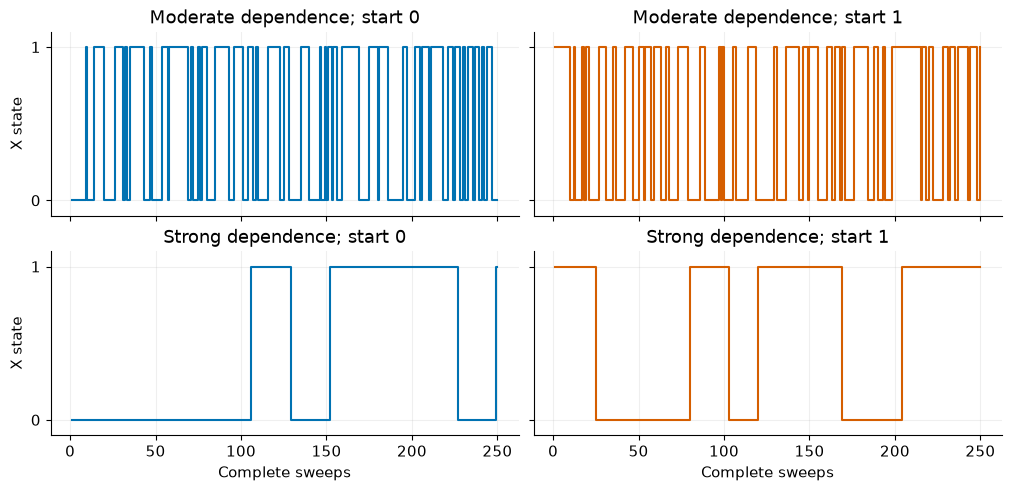

In [15]:
# 把更多概率放在对角状态，构造更强依赖的对照目标分布。
slow_joint = np.array([[0.495, 0.005], [0.005, 0.495]])
rng_comparison = np.random.default_rng(2806)
comparison_runs = {}
# 每种目标分布分别从两个起点运行；同一生成器继续抽样，不重置种子。
for name, table in [("Moderate dependence", joint), ("Strong dependence", slow_joint)]:
    comparison_runs[name] = [
        gibbs_binary(table, start, 6000, rng_comparison) for start in [(0, 0), (1, 1)]
    ]

fig, axes = plt.subplots(
    2, 2, figsize=(10, 4.8), sharex=True, sharey=True, layout="constrained"
)
# 图的行区分目标分布，列区分起点；每幅只画前 250 轮的 X 状态。
for row, (name, runs) in enumerate(comparison_runs.items()):
    for column, draws in enumerate(runs):
        axes[row, column].step(
            np.arange(1, 251),
            draws[:250, 0],
            where="post",
            color=["#0072B2", "#D55E00"][column],
        )
        axes[row, column].set(
            title=f"{name}; start {column}", yticks=[0, 1], ylim=(-0.1, 1.1)
        )
        axes[row, column].grid(alpha=0.2)
for ax in axes[-1]:
    ax.set_xlabel("Complete sweeps")
for ax in axes[:, 0]:
    ax.set_ylabel("X state")
# 本次上排切换较频繁，下排有更长的 0/1 连续片段；横轴是一轮完整扫描。
plt.show()

## 10 有限运行的检查与边界

常见做法是舍弃一段初始记录，称为预热或 burn-in，以减轻初始状态的影响。丢弃固定步数并不保证后续已经达到平稳，也不会使后续样本独立。下面选择舍弃 1000 次，仅作为这次教学实验的设定。

比较多个起点、前后段均值、状态频数和自相关，能发现部分明显问题；这些指标一致也不是收敛证明。本例另有明确的有限状态理论与已知目标可核对；实际未知目标时更不能只看一张轨迹图。

In [16]:
burn_in = 1000
for name, runs in comparison_runs.items():
    for index, draws in enumerate(runs):
        # 每行是一轮完整更新；去掉前 1000 轮，再将保留的 X 按时间分成两半。
        retained = draws[burn_in:]
        codes = 2 * retained[:, 0] + retained[:, 1]
        first_half, second_half = np.split(retained[:, 0], 2)
        # 本次四条链的 E[X] 估计约 0.5194、0.5042、0.5394、0.5516；分段均值展示各链波动。
        print(
            name,
            "起点",
            index,
            "E[X]估计",
            retained[:, 0].mean(),
            "前后段均值",
            first_half.mean(),
            second_half.mean(),
        )
        # 本次中等依赖两链接近 [0.4, 0.1, 0.1, 0.4]；强依赖两链的非对角比例约在 0.005～0.008。
        print("四状态比例：", np.bincount(codes, minlength=4) / codes.size)
        # 本次依次为 0.8008、0.7942、0.99、0.9852，分别对照目标 0.8、0.8、0.99、0.99。
        print("坐标相同的比例：", np.mean(retained[:, 0] == retained[:, 1]))
# 两个目标的 E[X] 都是 0.5，但 P(X=Y) 分别是 0.8 和 0.99，不能混用目标。

Moderate dependence 起点 0 E[X]估计 0.5194 前后段均值 0.5224 0.5164
四状态比例： [0.3824 0.0982 0.101  0.4184]
坐标相同的比例： 0.8008
Moderate dependence 起点 1 E[X]估计 0.5042 前后段均值 0.512 0.4964
四状态比例： [0.3916 0.1042 0.1016 0.4026]
坐标相同的比例： 0.7942
Strong dependence 起点 0 E[X]估计 0.5394 前后段均值 0.5664 0.5124
四状态比例： [0.456  0.0046 0.0054 0.534 ]
坐标相同的比例： 0.99
Strong dependence 起点 1 E[X]估计 0.5516 前后段均值 0.4668 0.6364
四状态比例： [0.4414 0.007  0.0078 0.5438]
坐标相同的比例： 0.9852


下面估计滞后 k 的自相关。对于一条长度 n 的数值序列 y，先减去该序列均值，记中心化值为 cₜ，再计算 ∑ₜ₌₁ⁿ⁻ᵏcₜcₜ₊ₖ / ∑ₜ₌₁ⁿcₜ²。它是有限样本的描述性估计；常数序列分母为零，不能解释为“相关性为零”。

图中只画滞后 1–40，不把这段截断直接包装成通用 ESS 估计器。完整诊断还要考虑链间差异与尾部行为；成熟工具的 ESS 与多链诊断有更完整的估计规则。

Moderate dependence 滞后 1 的样本自相关： 0.3612225377692604
Strong dependence 滞后 1 的样本自相关： 0.9635408471901757


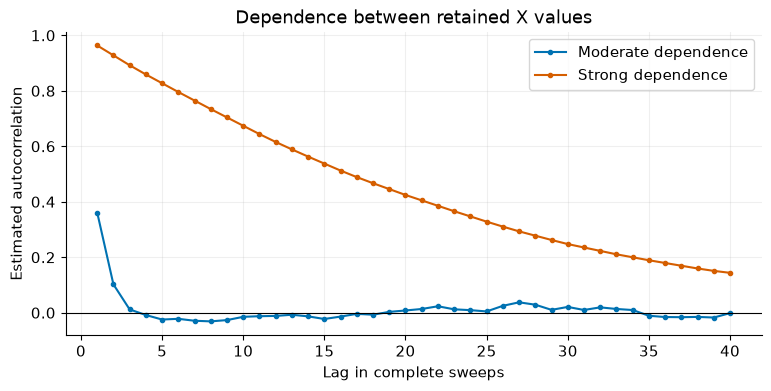

In [17]:
def autocorr(values, max_lag):
    """本章描述性自相关；输入需有非零样本方差。"""
    # 输入需有非零样本方差；先减均值，以总平方偏差作为共同分母。
    centered = values - values.mean()
    denominator = centered @ centered
    # 两段切片相隔 lag 轮，对齐相乘后求和，lag 从 1 到 max_lag。
    return np.array(
        [
            centered[:-lag] @ centered[lag:] / denominator
            for lag in range(1, max_lag + 1)
        ]
    )


fig, ax = plt.subplots(figsize=(7.6, 3.8), layout="constrained")
# 只比较第一条链丢弃 burn_in 轮后的 X，横轴单位是完整 Gibbs 轮次。
for (name, runs), color in zip(comparison_runs.items(), ["#0072B2", "#D55E00"]):
    correlations = autocorr(runs[0][burn_in:, 0], 40)
    ax.plot(np.arange(1, 41), correlations, "o-", markersize=3, color=color, label=name)
    print(name, "滞后 1 的样本自相关：", correlations[0])  # 本次中等、强依赖链的滞后 1 自相关分别约 0.3612、0.9635。
ax.axhline(0, color="black", linewidth=0.8)
ax.set(
    xlabel="Lag in complete sweeps",
    ylabel="Estimated autocorrelation",
    title="Dependence between retained X values",
)
ax.legend()
ax.grid(alpha=0.2)
# 本次强依赖链的相关性随滞后衰减较慢；中等依赖链更快降至零附近并有样本波动。
plt.show()

抽稀（thinning）指每隔若干步只保留一个状态。它可能降低保留序列的相邻相关性，但也丢弃数据；相同总计算量下，不等于凭空增加独立信息。为了节省存储可以考虑抽稀，不能用它替代混合与收敛检查。

更严重的边界是目标只在 (0,0)、(1,1) 有概率，均为 0.5。单坐标 Gibbs 从其中一个状态出发无法到另一个；链不再不可约。下面保留这个反例：增加长度或预热都无法跨越由零概率造成的断开支持。

In [18]:
disconnected_joint = np.array([[0.5, 0.0], [0.0, 0.5]])
for initial_pair in [(0, 0), (1, 1)]:
    trapped = gibbs_binary(
        disconnected_joint, initial_pair, 1000, np.random.default_rng(2807)
    )
    # 从 (0, 0) 只访问 (0, 0)，均值为 0；从 (1, 1) 只访问 (1, 1)，均值为 1。
    print(
        "起点",
        initial_pair,
        "实际访问状态",
        np.unique(trapped, axis=0),
        "X 均值",
        trapped[:, 0].mean(),
    )
# 目标 E[X]=0.5；两条链却分别永远停在 0 和 1。
# 把两个各自困住的结果合并成 0.5，也不能证明单条链能正确探索目标。

起点 (0, 0) 实际访问状态 [[0 0]] X 均值 0.0
起点 (1, 1) 实际访问状态 [[1 1]] X 均值 1.0


## 本章小结

（1）行随机转移矩阵通过 μₜ₊₁=μₜP 推进分布；模拟路径则根据当前位置选择下一步。两者描述不同对象。

（2）πP=π 表示平稳。有限不可约链有唯一平稳分布与时间平均保证；再有非周期条件，任意起点的逐时刻分布也趋于 π。

（3）MCMC 状态通常相关，均值方差包含协方差项。有效样本量取决于观察的函数与相关性，记录数量不等于独立信息数量。

（4）Gibbs 使用目标条件分布更新坐标。必须检查更新顺序、目标保持性和支持条件；预热、抽稀及好看的轨迹都不能替代这些条件。

理解自查：一条链的每一步边际分布都相同，是否意味着相邻样本独立？两条链的均值恰好相同，是否足以排除它们遗漏同一片状态区域？

## 练习

（1）把两状态转移矩阵改为 [[0.9,0.1],[0.4,0.6]]。手算平稳分布，从两个确定起点计算 1、2、10 步的分布，再模拟一条长路径。分别说明矩阵乘法误差与有限采样误差应如何判断。

In [19]:
exercise_transition = np.array([[0.9, 0.1], [0.4, 0.6]])
exercise_rng = np.random.default_rng(2821)
# 写出平稳方程与归一化约束，再核对分布更新和长期访问比例。

（2）设每步必定翻转的两状态链从 0 开始。比较第 n 步的分布与前 n 步访问状态 1 的比例，分别取奇数、偶数 n。说明为什么时间平均可以趋于 1/2，而逐时刻分布不收敛。

In [20]:
exercise_alternating = np.array([[0.0, 1.0], [1.0, 0.0]])
exercise_lengths = [9, 10, 99, 100]
# 明确是否包含初始状态，保持分母与实际记录数量一致。

（3）对称翻转链取 a=0.1，长度 n=500。根据 ρₖ=(1−2a)ᵏ 计算平稳起点下的均值方差和渐近 ESS，模拟至少 500 条独立初始化的链核对。再把所有起点固定为 0，解释为何原先的平稳协方差推导不能不加说明直接套用。

In [21]:
exercise_flip = 0.1
exercise_chain_length = 500
exercise_repetitions = 500
exercise_chain_rng = np.random.default_rng(2823)
# 先用 π 初始化每条链，再比较固定起点；不得把链内记录当作独立重复。

（4）目标联合表改为 [[0.3,0.2],[0.1,0.4]]。手算两组条件概率，构造完整扫描矩阵并核对 πK=π，再从多个初始状态运行 Gibbs。检查 E[X] 与 P(X=Y) 两个不同目标；说明为什么只核对第一个均值还不足以检查整个联合分布。

In [22]:
exercise_joint = np.array([[0.3, 0.2], [0.1, 0.4]])
exercise_gibbs_rng = np.random.default_rng(2824)
# 条件概率分别沿列、沿行归一化；完整扫描必须使用已更新的 X。

## 练习提示与解析

以下对应练习（2）。先独立作答，卡住时依次查看提示，完成后再对照解析。

提示 1：从 0 开始写出状态序列；先声明统计记录是否包含初始状态。

提示 2：逐时刻分布只看某一步，时间平均汇总前面的多步。

### 练习（2）参考解析

采用不含初始状态的记录 $X_1,\ldots,X_n$，序列为 1、0、1、0……。奇数步的分布为 $(0,1)$，偶数步为 $(1,0)$，两者交替，逐时刻分布不收敛。

前 n 步访问 1 的比例是 $\lceil n/2\rceil/n$：n=9、10、99、100 时分别为 $5/9$、$1/2$、$50/99$、$1/2$，都逐渐趋近 1/2。周期性阻止此起点的分布收敛，却不阻止这个时间平均收敛。若改为包含初始状态，须同时改变计数范围与分母。

## 参考与引用来源

本章新增示意图由 CMYK Labs 原创，依据下表对应概念与本章教学输入绘制；示意图不作为实际运行截图或数学证明。

| 网站 | 本章参考内容与定位 |
| --- | --- |
| MMiDS 作者网站 | Sébastien Roch：[§7.2](https://mmids-textbook.github.io/chap07_rwmc/02_mcdefs/roch-mmids-rwmc-mcdefs.html)，§7.2.1–7.2.2，马尔可夫性质、时间齐次、行随机矩阵与分布推进；[§7.3](https://mmids-textbook.github.io/chap07_rwmc/03_stat/roch-mmids-rwmc-stat.html)，Stationary Distribution、Irreducibility 与唯一性定理；[§7.4](https://mmids-textbook.github.io/chap07_rwmc/04_mclimit/roch-mmids-rwmc-mclimit.html)，§7.4.1–7.4.2，周期反例、非周期充分条件、分布收敛及遍历定理；[§7.6](https://mmids-textbook.github.io/chap07_rwmc/06_gibbs/roch-mmids-rwmc-gibbs.html)，§7.6.1–7.6.2，MCMC 与从目标条件分布更新坐标。本章的二元表、顺序扫描平稳性展开及实验另行构造。 |
| Deep Learning 作者网站 | Goodfellow、Bengio、Courville，[Chapter 17](https://www.deeplearningbook.org/contents/monte_carlo.html)，§17.3 马尔可夫更新与目标分布；§17.4 Gibbs、条件独立时的分块更新；§17.5 强依赖和分离模式导致的混合困难。本章使用行概率向量，矩阵布局与书中的列向量约定相应转置。 |
| Stan 官方文档 | Stan 2.40，[Posterior Analysis](https://mc-stan.org/docs/reference-manual/analysis.html)，Convergence、Convergence is global：渐近保证、有限诊断与舍弃预热的局限；Effective sample size 的 Definition、Estimation、MCMC standard error：自相关、ESS、不同目标与估计误差；Thinning：相关性、记录数量及存储取舍。本章只用解析两状态链解释方差，不实现 Stan 的诊断器，也无需安装 Stan。 |
| NumPy 官方文档 | NumPy 2.5：[Generator.choice](https://numpy.org/doc/stable/reference/random/generated/numpy.random.Generator.choice.html)，p 与抽样；[Generator.random](https://numpy.org/doc/stable/reference/random/generated/numpy.random.Generator.random.html)，均匀数生成；[Compatibility policy](https://numpy.org/doc/stable/reference/random/compatibility.html)，复现条件；[matrix_power](https://numpy.org/doc/stable/reference/generated/numpy.linalg.matrix_power.html)，矩阵整数次幂；[bincount](https://numpy.org/doc/stable/reference/generated/numpy.bincount.html)，非负整数编号计数。 |
| Matplotlib 官方文档 | Matplotlib 3.11：[Axes.plot](https://matplotlib.org/stable/api/_as_gen/matplotlib.axes.Axes.plot.html)，分布曲线与相关性曲线；[Axes.step](https://matplotlib.org/stable/api/_as_gen/matplotlib.axes.Axes.step.html)，where=post 下的离散状态轨迹。 |